In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#chargement du dataset
df=pd.read_csv('creditcard.csv')
#verification de base pour le nettoyage
print(f'nombre de lignes : {df.shape[0]}')
print(f'valeurs manquantes : {df.isnull().sum().max()}')
print(f'doublons : {df.duplicated().sum()}')
#suppression des doublons pour avoir des données saines
df.drop_duplicates(inplace=True)

nombre de lignes : 284807
valeurs manquantes : 0
doublons : 1081


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**ANALYSE UNIVARIEE**

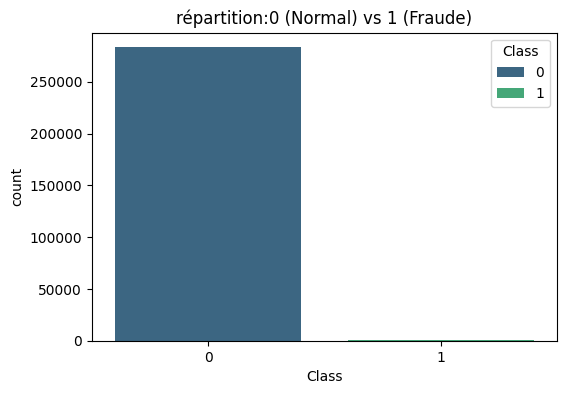

Taux de fraude : 0.17%


In [11]:
#desequilibre des classes
plt.figure(figsize=(6,4))
sns.countplot(x='Class',data=df,hue='Class',palette='viridis')
plt.title('répartition:0 (Normal) vs 1 (Fraude)')
plt.show()
#calcul du pourcentage exact de fraude
fraude = (df['Class'].value_counts()[1]/len(df))*100
print(f'Taux de fraude : {fraude:.2f}%')

On constate que le taux de fraude est très faible. Pour eviter l'erreur et mieux analyser la donnée il faudra isoler les fraudes au max 

**DIPERSION DES TRANSACTIONS**

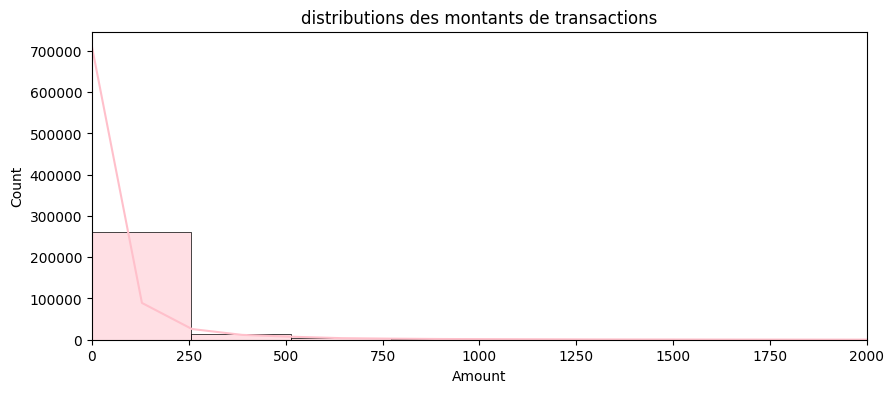

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'], bins=100,kde=True,color='pink')
plt.title('distributions des montants de transactions')
plt.xlim([0,2000])#LIMITE LA DISTRIBUTION DES DONNEES
plt.show()

Par ce graphique on comprends bien que les montants de transaction sont entre 0 et 250 et on observe une chutte drastique. Le mieux serait de normaliser les valeurs (loi normale centrée) et puis de vérifier si les fraudes ne suivent pas la même courbe.

C:\Users\PC\AppData\Local\Temp\ipykernel_1920\1774679911.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class']==0]['Amount'],label='Normal',shade=True, color='blue')
C:\Users\PC\AppData\Local\Temp\ipykernel_1920\1774679911.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class']==1]['Amount'],label='Fraude',shade=True,color='red')


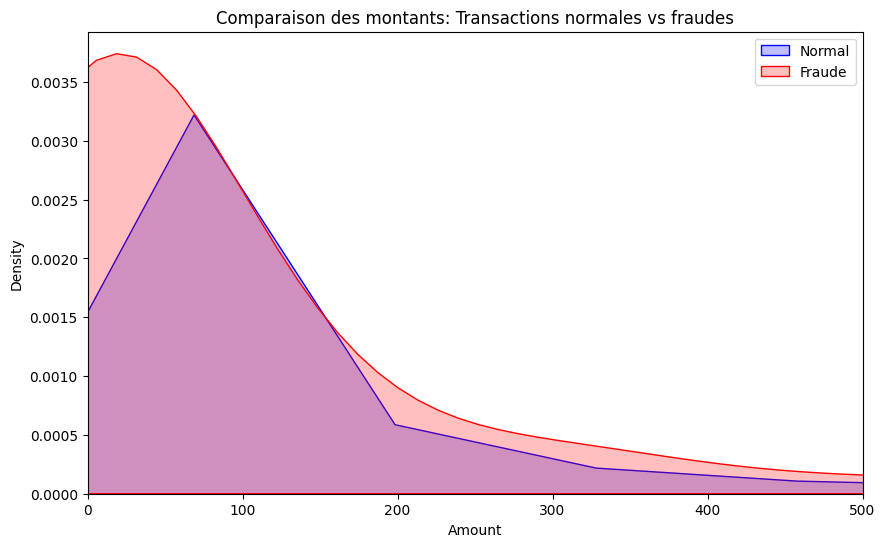

In [14]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['Class']==0]['Amount'],label='Normal',shade=True, color='blue')
sns.kdeplot(df[df['Class']==1]['Amount'],label='Fraude',shade=True,color='red')
plt.xlim([0,500])
plt.title('Comparaison des montants: Transactions normales vs fraudes')
plt.legend()
plt.show()

on constate que les montants de transaction frauduleuses sont confuses avec les montants de transaction normale. Ce que nous allons faire est de lever le doute sur la fraude en équilibrant le dataset(50% normal et 50% fraude).

### Creation du dataset équilibré ###

In [21]:
#mélange des données pour obtenir des valeurs aléatoires
df=df.sample(frac=1)
#on récupère toutes les fraudes
fraud_df=df.loc[df['Class']==1]
#On récupère exactement autant de valeurs normales que de fraude
non_fraud=df.loc[df['Class']==0][:len(fraud_df)]
#on rassemble les données ensemble
normal_distributed_df=pd.concat([fraud_df,non_fraud])
#on mélange de nouveaux
new_df=normal_distributed_df.sample(frac=1,random_state=42)

**Affichage de la carte de chaleur**

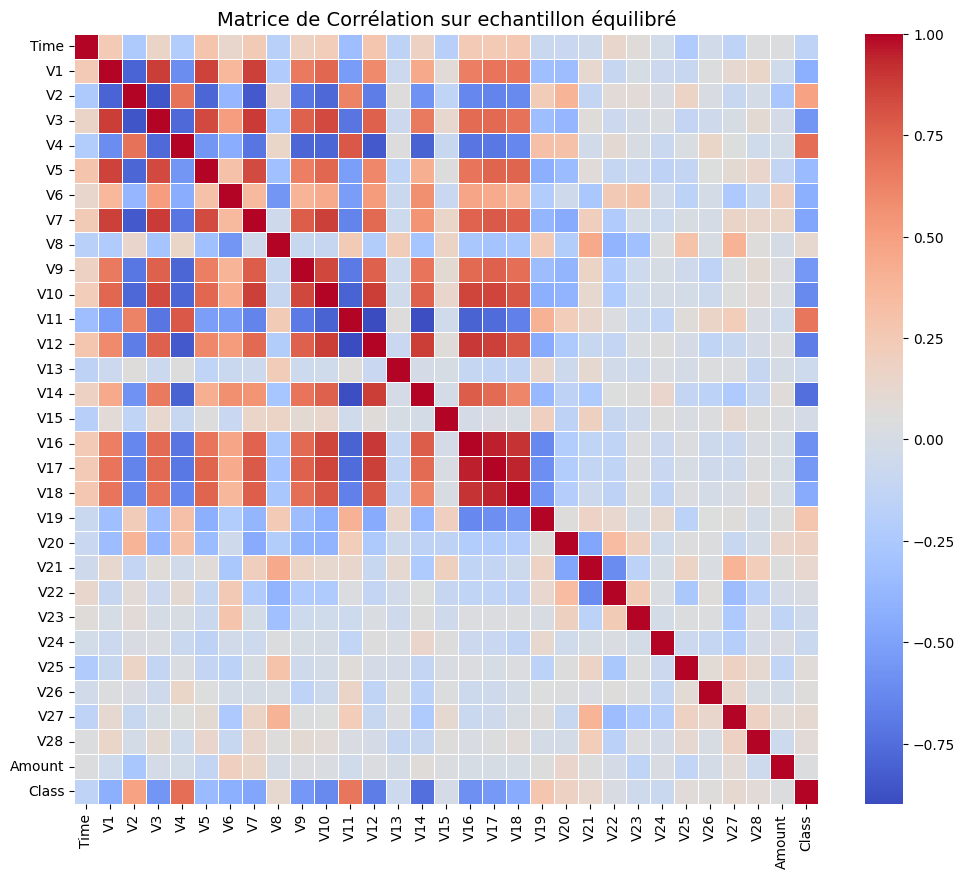

In [18]:
plt.figure(figsize=(12,10))
sub_sample_correlation=new_df.corr()
sns.heatmap(sub_sample_correlation,cmap='coolwarm',annot=False,linewidth=0.5)
plt.title('Matrice de Corrélation sur echantillon équilibré',fontsize=14)
plt.show()

on voit sur la colonne et ligne class(car c'est lui qui dit si c'est une fraude ou pas) une forte correlation négative entre V12 et V14 alors si l'un augmente l'autre baisse. Alors c'est un indice de fraude. Si ces deux paramètres nous aide a savoir si c'est une fraude ou pas, nous allons lever le doute en affichant la correlation entre ces deux variables.

In [22]:
print(f"Corrélation exacte entre V12 et V14 : {new_df['V12'].corr(new_df['V14']):.2f}")

Corrélation exacte entre V12 et V14 : 0.88


cette forte correlation positive entr V12 et V14 nous montre que ces deux variables nous donne la meme information et donc il ya **multicolinéarité** donc en gardant une variable on ne perd pas d'information. Mais l'on observe qu'avec le colonne classe il ya une forte correlation négative qui est un indicateur de fraude alors vérifions.

In [24]:
print(f'correlation exacte entre V12 et Class : {new_df['V12'].corr(new_df['Class']):.2f}')

correlation exacte entre V12 et Class : -0.67


Maintenant que nous sommes sure que V12 et V14 sont des variables imporantes pour la fraude nous allons procéder au nettoyage du signal de variables.

## NETTOYAGE DE VARIABLES ##

<function matplotlib.pyplot.show(close=None, block=None)>

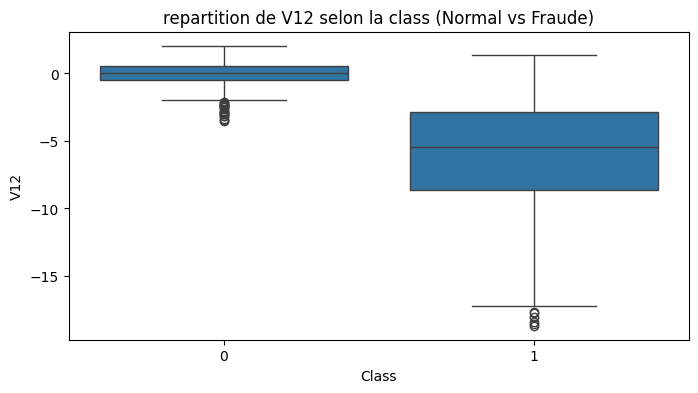

In [25]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='V12', data=new_df)
plt.title('repartition de V12 selon la class (Normal vs Fraude)')
plt.show

Ce boxplot nous montre que quand la class est normale (0) V12 est centré en 0, donc V12 Grand signifie fraude faible. Par contre quand la classe est une fraude(1) la valeur de V12 diminue. Notre intuition est donc bonne.

Nous voyons également les outliers par exemples les faux positifs sur la class 0 et des fraudes trop importantes au niveau de class 1 voila pourquoi le nettoyage est important pour réduire ces dispersions

### DATA CLEANING ###

Pour le faire on va utiliser la méthode **IQR** qui va nous aider a définir un intervalle et supprimer les valeurs abbérentes
1. Calculer les Quartiles ($Q1$ et $Q3$):
On divise tes données en quatre parts égales :
Q1 (25%) : La valeur qui sépare les 25 % les plus bas.
Q3 (75%) : La valeur qui sépare les 75 % les plus bas.L'IQR est simplement la différence : $IQR = Q3 - Q1$. C'est la largeur du "bloc bleu" que tu as vu sur ton boxplot.
3. Définir les "Barres de Sécurité" (Whiskers):
Pour savoir si un point est un "outlier" (une anomalie), on utilise un multiplicateur standard, généralement 1.5.Borne Inférieure : $Q1 - (1.5 \times IQR)$Borne Supérieure : $Q3 + (1.5 \times IQR)$

In [26]:
import numpy as np
# 1. Calculer l'IQR pour V12 (uniquement sur les cas de fraude)
V12_fraud=new_df['V12'].loc[new_df['Class']==1].values
q25= np.percentile(V12_fraud,25)
q75=np.percentile(V12_fraud,75)
IQR=q75-q25
#Définition de la borne basse car le bruit est a ce niveau
nettoyage=q25-(1.5*IQR)
# 3. Supprimer les lignes qui sont sous cette borne
new_df = new_df.drop(new_df[(new_df['V12'] < nettoyage) & (new_df['Class'] == 1)].index)

print(f"La borne inférieure calculée est : {nettoyage:.2f}")


La borne inférieure calculée est : -17.27


on n'a pas supprimer les faux positifs juste les valeurs abbérentes pour apprendre a notre modèle que ces cas existent egalement.

**nettoyons maintenant v14**

<function matplotlib.pyplot.show(close=None, block=None)>

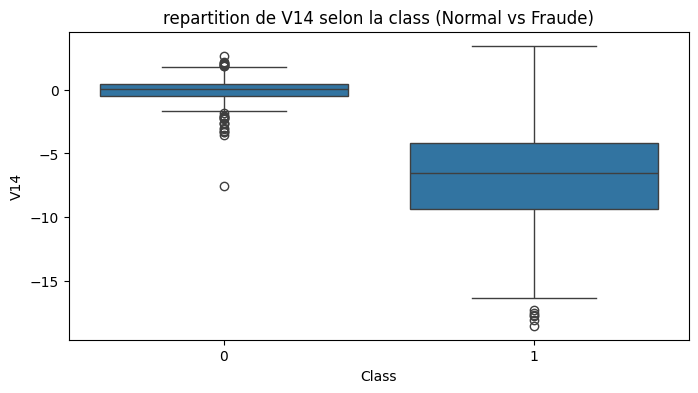

In [28]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='V14', data=new_df)
plt.title('repartition de V14 selon la class (Normal vs Fraude)')
plt.show

import numpy as np
# 1. Calculer l'IQR pour V12 (uniquement sur les cas de fraude)
V14_fraud=new_df['V14'].loc[new_df['Class']==1].values
q25= np.percentile(V14_fraud,25)
q75=np.percentile(V14_fraud,75)
IQR=q75-q25
#Définition de la borne basse car le bruit est a ce niveau
nettoyage=q25-(1.5*IQR)
# 3. Supprimer les lignes qui sont sous cette borne
new_df = new_df.drop(new_df[(new_df['V14'] < nettoyage) & (new_df['Class'] == 1)].index)

print(f"La borne inférieure calculée est : {nettoyage:.2f}")


Ce nettoyage permet que le modele ne se concentre pas sur des valeurs trop isolées et soit précis

**model training et evaluation**
1. separation de variable

In [30]:
# X = toutes les colonnes sauf 'Class'
X = new_df.drop('Class', axis=1)

# y = uniquement la colonne 'Class'
y = new_df['Class']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Le Training Set (80%) : Les exercices que le modèle va faire pour apprendre.

Le Test Set (20%) : L'examen final. Le modèle ne voit jamais ces données pendant l'apprentissage. C'est ici qu'on verra s'il fait des Faux Positifs

## Entrainement du modele ##
**MODELE DE REGRESSION LOGISTIQUE**

In [36]:
from sklearn.linear_model import LogisticRegression

# Initialisation du modèle
model = LogisticRegression(max_iter=2500)

# Apprentissage 
model.fit(X_train, y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

ICI Le modele cherche a separer en deux grand groupe (normal et fraude) les transactions

l'erreur précédent nous montre qu'il faut normaliser les variables

In [49]:
from sklearn.preprocessing import StandardScaler
# 1. Créer le scaler
scaler = StandardScaler()

# 2. On ajuste et on transforme les données d'entraînement
# C'est ici que l'algorithme apprend la moyenne et l'écart-type
X_train_scaled = scaler.fit_transform(X_train)

# 3. On transforme les données de test 
X_test_scaled = scaler.transform(X_test)

# 4. On lance le modèle 
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Convergence réussie, le modèle a trouvé la solution.")

Convergence réussie, le modèle a trouvé la solution.


In [40]:
# Le modèle fait ses pronostics sur l'examen final avec les valeurs non entrainés par le modele
y_pred = model.predict(X_test_scaled)

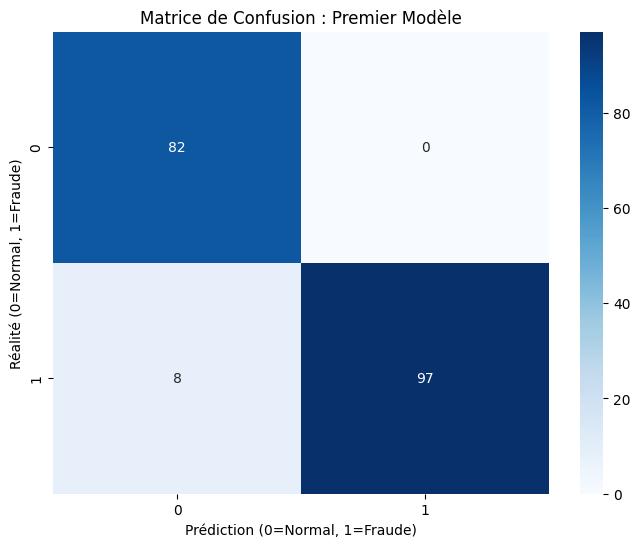

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        82
           1       1.00      0.92      0.96       105

    accuracy                           0.96       187
   macro avg       0.96      0.96      0.96       187
weighted avg       0.96      0.96      0.96       187



In [44]:
#ETAPE DE SCORING
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage graphique
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion : Premier Modèle')
plt.show()

# Rapport détaillé
print(classification_report(y_test, y_pred))

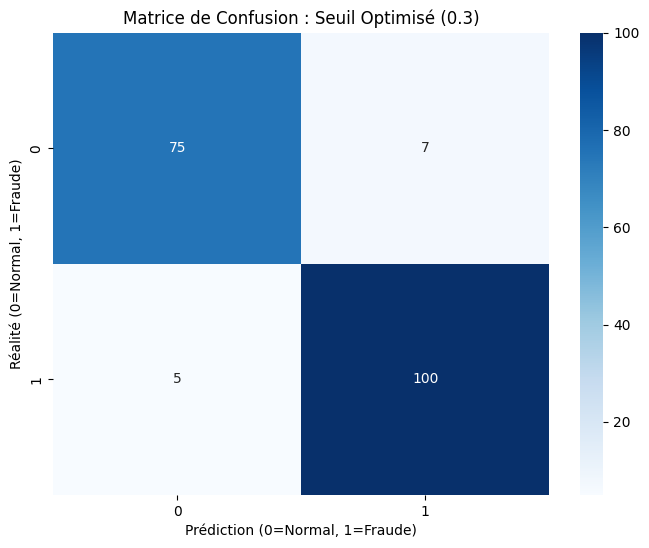

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#probalité de fraude
y_probs = model.predict_proba(X_test_scaled)[:,1]
# On baisse le seuil à 0.3 (on est plus sévère avec les fraudeurs)
y_pred_custom = (y_probs > 0.3).astype(int)
# 2. On crée la variable 'cm' pour le dessin
cm = confusion_matrix(y_test, y_pred_custom)

# 3. On dessine la matrice (exactement comme la précédente)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion : Seuil Optimisé (0.3)')
plt.show()


J'ai ajusté le modele pour mininiser les fraudes considérées comme normales quitte a ne pas satisfaire les clients normaux mais tout dépends de de l'objectifs de l'entreprise 

### Maintenant attaquons le RANDOM FOREST ###

In [52]:
from sklearn.ensemble import RandomForestClassifier
#creation du modele
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
#entrainement du model sur les données
rf_model.fit(X_train_scaled, y_train)
#prediction
y_pred_rf = rf_model.predict(X_test_scaled)
print("fin de l'entraînement Random Forest")

fin de l'entraînement Random Forest


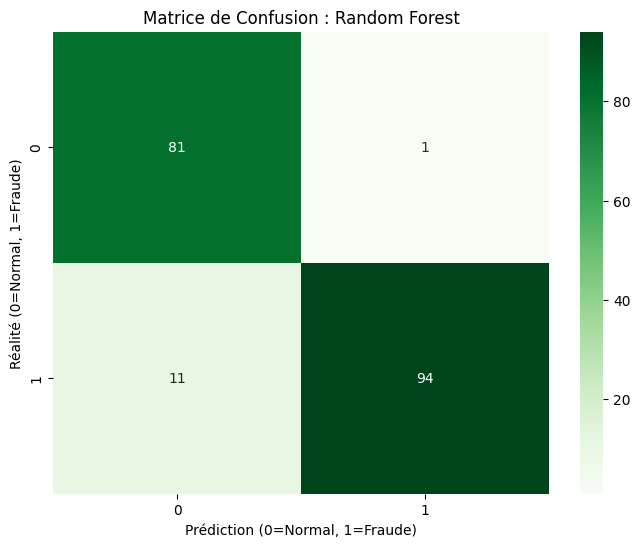

              precision    recall  f1-score   support

           0       0.88      0.99      0.93        82
           1       0.99      0.90      0.94       105

    accuracy                           0.94       187
   macro avg       0.93      0.94      0.94       187
weighted avg       0.94      0.94      0.94       187



In [53]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice pour le Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens') 
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion : Random Forest')
plt.show()

print(classification_report(y_test, y_pred_rf))

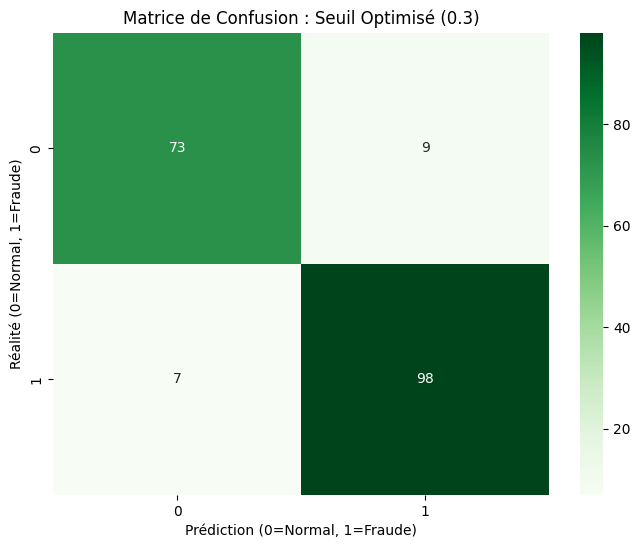

In [55]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#probalité de fraude
y_probs = rf_model.predict_proba(X_test_scaled)[:,1]
# On baisse le seuil à 0.3 (on est plus sévère avec les fraudeurs)
y_pred_custom = (y_probs > 0.3).astype(int)
# 2. On crée la variable 'cm' pour le dessin
cm = confusion_matrix(y_test, y_pred_custom)

# 3. On dessine la matrice (exactement comme la précédente)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion : Seuil Optimisé (0.3)')
plt.show()


on voit que le modele de regression logistique est plus précis que le random forest donc du coup pn va l'utiliser sur le dataset entier

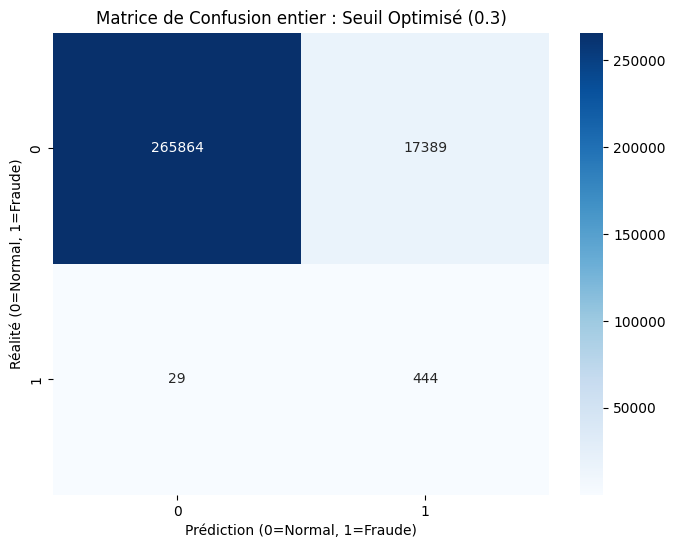

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    283253
           1       0.02      0.94      0.05       473

    accuracy                           0.94    283726
   macro avg       0.51      0.94      0.51    283726
weighted avg       1.00      0.94      0.97    283726



In [67]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
X_final = df.drop('Class', axis=1)
y_final = df['Class']
#probalité de fraude
X_scaled = scaler.transform(X_final)
y_probs_entier = model.predict_proba(X_scaled)[:,1]
# On baisse le seuil à 0.3 (on est plus sévère avec les fraudeurs)
y_pred_custom_entier = (y_probs_entier > 0.3).astype(int)
# 2. On crée la variable 'cm' pour le dessin
cm_entier= confusion_matrix(y_final, y_pred_custom_entier)

# 3. On dessine la matrice (exactement comme la précédente)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_entier, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion entier : Seuil Optimisé (0.3)')
plt.show()
print(classification_report(y_final,y_pred_custom_entier))

## Random Forest sur l'echantillon tout entier ##

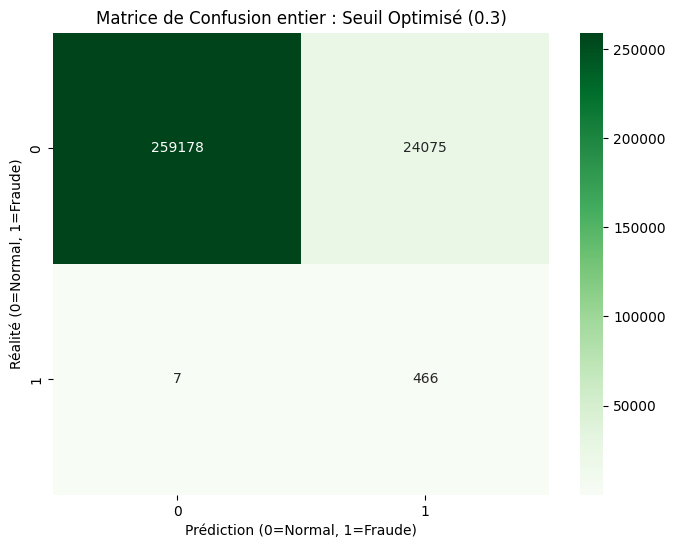

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    283253
           1       0.02      0.99      0.04       473

    accuracy                           0.92    283726
   macro avg       0.51      0.95      0.50    283726
weighted avg       1.00      0.92      0.95    283726



In [66]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
X_final = df.drop('Class', axis=1)
y_final = df['Class']
#probalité de fraude
X_scaled = scaler.transform(X_final)
y_probs_entier = rf_model.predict_proba(X_scaled)[:,1]
# On baisse le seuil à 0.3 (on est plus sévère avec les fraudeurs)
y_pred_custom_entier = (y_probs_entier > 0.3).astype(int)
# 2. On crée la variable 'cm' pour le dessin
cm_entier= confusion_matrix(y_final, y_pred_custom_entier)

# 3. On dessine la matrice (exactement comme la précédente)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_entier, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Prédiction (0=Normal, 1=Fraude)')
plt.ylabel('Réalité (0=Normal, 1=Fraude)')
plt.title('Matrice de Confusion entier : Seuil Optimisé (0.3)')
plt.show()
print(classification_report(y_final,y_pred_custom_entier))

Le Random Forest offre une sécurité quasi-totale. Bien qu'il génère plus de faux positifs que la régression logistique